# Comparing cross-talk normal rabi-drive and ccd

### Thoughts
- as in SMART paper, should we use average power to compare
    - andrew pointed out - in phase modulated this is always the same  - however the cheats method this is different??
    - no solong as I reduces the rabi freq for that aswell??

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import hamiltonians as hamiltonians
from pauli_matrices import *
import quantum_tools as qt

## Identiy on first qubit


## Root X on first qubit

First qubit on resonance - exibiting root x  
Second qubit should be idling


# Rabi Drive

In [3]:
# Create a quantum system with a single qubit
natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz



# Integration parameters
tol = 10**-7
evaluation_points = 2000
evaluation_time = 2000 # this is 1000ns

In [4]:
# root x gate matrix
root_x = np.array([[1/np.sqrt(2), -1j/np.sqrt(2)], [-1j/np.sqrt(2), 1/np.sqrt(2)]])

In [ ]:
detunings = np.linspace(-0.02, 0.02, 1000)

fids_1 = []
fids_2 = []
fids_combined = []

times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+0, driving_freq=driving_freq, rabi_freq=rabi_freq)
fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)


for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)

    fids_1.append(fid_1)

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)

    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

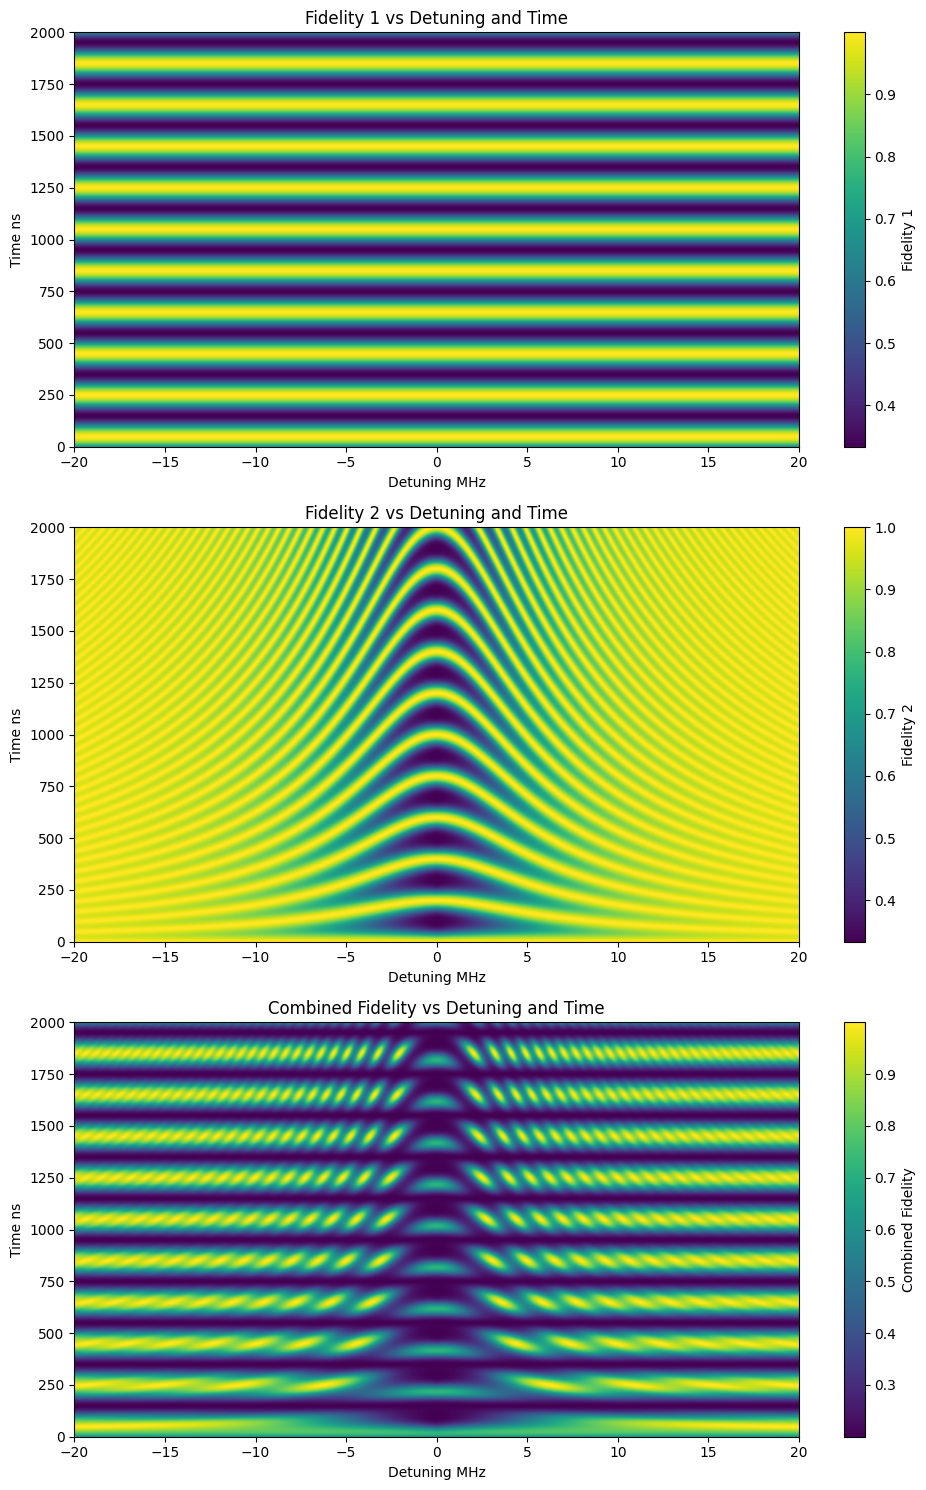

In [17]:
#detunings to MHz 
detunings_mhz = detunings * 10**3

#create three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

#plot fids_1
im1 = ax1.imshow(np.array(fids_1).T, aspect='auto', 
                 extent=[detunings_mhz[0], detunings_mhz[-1], times[0], times[-1]], 
                 origin='lower', cmap='viridis')
plt.colorbar(im1, ax=ax1, label='Fidelity 1')
ax1.set_xlabel('Detuning MHz')
ax1.set_ylabel('Time ns')
ax1.set_title('Fidelity 1 vs Detuning and Time')

#plot fids_2
im2 = ax2.imshow(np.array(fids_2).T, aspect='auto',
                 extent=[detunings_mhz[0], detunings_mhz[-1], times[0], times[-1]],
                 origin='lower', cmap='viridis')
plt.colorbar(im2, ax=ax2, label='Fidelity 2')
ax2.set_xlabel('Detuning MHz')
ax2.set_ylabel('Time ns')
ax2.set_title('Fidelity 2 vs Detuning and Time')

#plot fids_combined
im3 = ax3.imshow(np.array(fids_combined).T, aspect='auto',
                 extent=[detunings_mhz[0], detunings_mhz[-1], times[0], times[-1]],
                 origin='lower', cmap='viridis')
plt.colorbar(im3, ax=ax3, label='Combined Fidelity')
ax3.set_xlabel('Detuning MHz')
ax3.set_ylabel('Time ns')
ax3.set_title('Combined Fidelity vs Detuning and Time')

plt.tight_layout()
plt.show()

so obviously this is only valid for the lines that are the root x - but this looks good